In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading data

In [37]:
data_file = "VAL_THO_GF.xlsx"

# excel column to English mapping
cols = {
    'Datum': 'date',
    'Fachabteilung': 'dept',
    'Saal': 'room',
    'Notfallkategorie': 'priority',
    'procedureData_originductionmethod': 'anes-method',

    'In Schleuse': 'arrival-airlock',
    'In Einleitung': 'arrival-induction',
    'documented_anesthesiastarttimestamp': 'anes-start',
    'documented_anesthesiareleasetimestamp': 'anes-release',
    'documented_incisiontimestamp': 'incision',
    'auxilaryData_anesthesiaStartTimestamp': 'planned-anes-start',
    'auxilaryData_anesthesiaReleaseTimestamp': 'planned-anes-release',
    'auxilaryData_incisionTimestamp': 'planned-incision',
    'auxilaryData_expectedAnesthesiaReleaseTimestamp': 'expected-anes-release',
}

# columns with time information
time_cols = ['arrival-airlock', 'arrival-induction', 'anes-start', 'anes-release', 'incision', 'planned-anes-start', 'planned-anes-release', 'planned-incision', 'expected-anes-release']

# loading data
df = pd.read_excel("data/" + data_file, header=0, usecols=cols.keys(), dtype=str)
df = df.rename(columns=cols)

# converting time columns to datetime
for col in time_cols:
    if col in df.columns:
        col_data = df[col]
        if col_data.str.contains(r'\d{4}-\d{2}-\d{2}').any():
            timestamps = pd.to_datetime(col_data, format='%Y-%m-%d %H:%M:%S', errors='coerce')
        elif col_data.str.contains(r'\d{2}\.\d{2}\.\d{4}').any():
            timestamps = pd.to_datetime(col_data, dayfirst=True, errors='coerce')
        df[col] = timestamps

# calculating wait time for anesthesia
df['best-arrival'] = df['arrival-induction'].fillna(df['arrival-airlock'])
df['wait_for_anes_min'] = (df['anes-start'] - df['best-arrival']).dt.total_seconds() / 60
df.loc[df['wait_for_anes_min'] < 0, 'wait_for_anes_min'] = 0

# calculating schedule delays
df['delay_start_min'] = (df['anes-start'] - df['planned-anes-start']).dt.total_seconds() / 60
df['delay_release_min'] = (df['anes-release'] - df['planned-anes-release']).dt.total_seconds() / 60
df['delay_incision_min'] = (df['incision'] - df['planned-incision']).dt.total_seconds() / 60
df['delay_release_exp_min'] = (df['anes-release'] - df['expected-anes-release']).dt.total_seconds() / 60

print("--- Average Logistics Metrics ---")
print(f"Average Physical Wait for Anesthesia: {df['wait_for_anes_min'].mean():.1f} mins")
print(f"Average Delay for Anesthesia Start:   {df['delay_start_min'].mean():.1f} mins")
print(f"Average Delay for Anesthesia Release: {df['delay_release_min'].mean():.1f} mins")
print(f"Average Delay for Incision (Surgery): {df['delay_incision_min'].mean():.1f} mins")
print(f"Average Delay for Anesthesia Release from expected value: {df['delay_release_exp_min'].mean():.1f} mins")

--- Average Logistics Metrics ---
Average Physical Wait for Anesthesia: 11.7 mins
Average Delay for Anesthesia Start:   0.0 mins
Average Delay for Anesthesia Release: 0.0 mins
Average Delay for Incision (Surgery): 0.1 mins
Average Delay for Anesthesia Release from expected value: 1.5 mins


# Split data based on clusters

In [38]:
clusters = [['OP2-08', 'OP2-09', 'OP2-10'],['OP2-11', 'OP2-12', 'OP2-13']]

all_rooms = df['room'].unique()
rooms_unused = set(all_rooms) - set(clusters[0]) - set(clusters[1])

print(f"Unused rooms: {rooms_unused}")

for c_idx, cluster in enumerate(clusters):
    df.loc[df['room'].isin(cluster), 'cluster'] = c_idx

Unused rooms: {'OP2-14', 'OP2-05', 'OP3-03', 'OP3-06', 'OP2-15', 'OP3-01', 'OP3-09', 'OP3-13', 'OP3-04', 'OP2-03', 'OP3-10', 'OP3-12', 'OP2-06', 'OP2-07', 'OP3-08', 'OP3-05', 'OP2-16', 'OP2-04', 'OP3-02', 'OP3-11', 'OP3-07'}


# Find number of neigbours / $\Delta t$

In [39]:
window_min = 10

for clust_idx, cluster in enumerate(clusters):
    clust_df = df[df['cluster'] == clust_idx]
    days = clust_df['date'].unique()

    for day in days:
        df_day = clust_df[clust_df['date'] == day]

        for room in clusters[clust_idx]:
            room_surgeries = df_day[df_day['room'] == room]

            other_rooms = [r for r in clusters[clust_idx] if r != room]
            for idx, surgery in room_surgeries.iterrows():
                curr_time = surgery['best-arrival']

                if pd.isna(curr_time):
                    continue

                closest_deltas = []

                for other_room in other_rooms:
                    other_room_surgeries = df_day[df_day['room'] == other_room]

                    if other_room_surgeries.empty:
                        continue

                    deltas = (other_room_surgeries['best-arrival'] - curr_time).dt.total_seconds() / 60
                    abs_deltas = deltas.dropna().abs()

                    if not abs_deltas.empty:
                        closest_deltas.append(abs_deltas.min())

                if len(closest_deltas) > 0:
                    num_neighbours = sum(d <= window_min for d in closest_deltas)
                    min_delta = min(closest_deltas)
                    avg_delta = sum(closest_deltas) / len(closest_deltas)
                else:
                    num_neighbours = 0
                    min_delta = 1440
                    avg_delta = 1440

                df.loc[idx, 'num_neighbours'] = num_neighbours
                df.loc[idx, 'min_delta'] = min_delta
                df.loc[idx, 'avg_delta'] = avg_delta


# Graph delay x neighbours

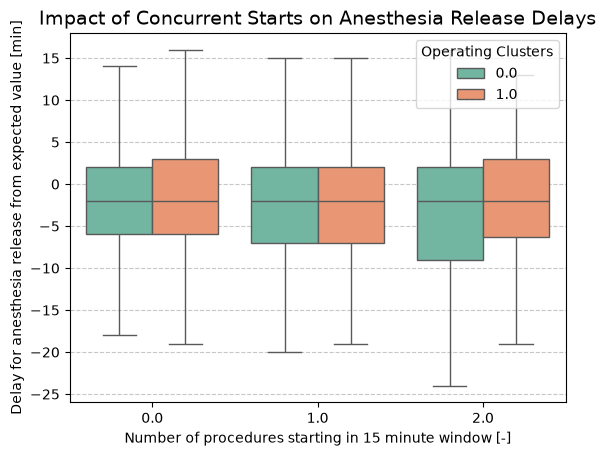

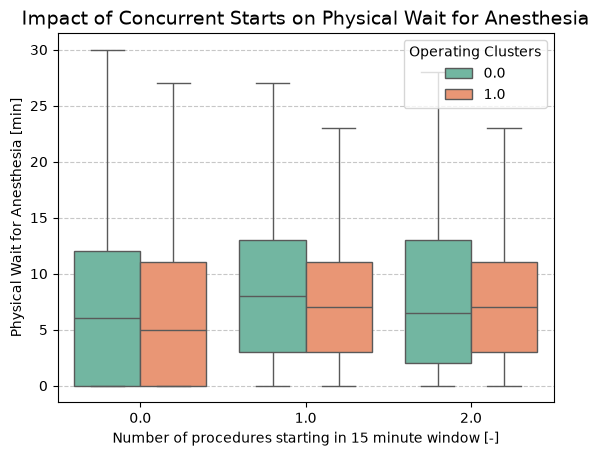

In [45]:
mask = (df['cluster'].notna())
df_plot = df[mask].copy()

plt.figure()
sns.boxplot(
    data=df_plot,
    x="num_neighbours",
    y="delay_release_exp_min",
    hue="cluster",
    palette="Set2",
    showfliers=False,
)
plt.xlabel("Number of procedures starting in 15 minute window [-]")
plt.ylabel("Delay for anesthesia release from expected value [min]")
plt.title("Impact of Concurrent Starts on Anesthesia Release Delays", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Operating Clusters")
plt.show()

plt.figure()
sns.boxplot(
    data=df_plot,
    x="num_neighbours",
    y="wait_for_anes_min",
    hue="cluster",
    palette="Set2",
    showfliers=False,
)
plt.xlabel("Number of procedures starting in 15 minute window [-]")
plt.ylabel("Physical Wait for Anesthesia [min]")
plt.title("Impact of Concurrent Starts on Physical Wait for Anesthesia", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Operating Clusters")
plt.show()